<a href="https://colab.research.google.com/github/SiddharthSB27/5V-POWER-SUPPLY-PCB/blob/main/workshop/V_SPACE_demo_280326_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## V-SPACE Bootcamp: From Verilog to Silicon

This interactive Google Colab notebook will:
* Install LibreLane and all required chip design dependencies directly in the cloud.
* Run our custom design, the **V-SPACE Demo Hardware Stopwatch** (a 1-second interval counter for a 7-segment display), through the complete physical design flow.
* Target the [open source sky130 PDK](https://github.com/google/skywater-pdk/) by Google and Skywater, generating a factory-ready GDSII layout for Tiny Tapeout.

In [ ]:
# @title Setup Nix {display-mode: "form"}
# @markdown <img src="https://raw.githubusercontent.com/NixOS/nixos-artwork/51a27e4a011e95cb559e37d32c44cf89b50f5154/logo/nix-snowflake-colours.svg" width="32"/>
# @markdown
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown and it is the primary method for installing LibreLane.
# @markdown
# @markdown This step installs the Nix package manager and enables the
# @markdown FOSSi Foundation Nix Cache.
# @markdown
# @markdown If you're not in a Colab, this just sets the environment variables.
# @markdown You will need to install Nix and enable flakes on your own following
# @markdown [this guide](https://librelane.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
from pathlib import Path
import subprocess
import sys
import shutil
import tempfile

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            d = Path(d)
            installer_path = d / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                [
                    "bash",
                    installer_path,
                    "install",
                    "--prefer-upstream-nix",
                    "--no-confirm",
                    "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\nextra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

In [5]:
# @title Get LibreLane {display-mode: "form"}
# @markdown Click the ▷ button to download and install LibreLane.
# @markdown
# @markdown This will install LibreLane's tool dependencies using Nix,
# @markdown and LibreLane itself using PIP.
# @markdown
# @markdown Note that `python3-tk` may need to be installed using your OS's
# @markdown package manager.
import os
import yaml
import subprocess
import IPython

librelane_version = "latest"  # @param {key:"LibreLane Version", type:"string"}

if librelane_version == "latest":
    librelane_version = "main"

pdk_root = "~/.ciel"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")

display(IPython.display.HTML("<h3>Downloading LibreLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {librelane_ipynb_path}
!mkdir -p {librelane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {librelane_ipynb_path}
else:
    !curl -L "https://github.com/librelane/librelane/tarball/{librelane_version}" | tar -xzC {librelane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading LibreLane's dependencies…</a>"))
try:
    with subprocess.Popen(
        [
            "nix",
            "profile",
            "install",
            ".#colab-env",
        ],
        cwd=librelane_ipynb_path,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        encoding="utf8",
    ) as p:
        for line in p.stdout:
            print(line, end="")
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=librelane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import ciel
from ciel.source import StaticWebDataSource

with open(
    os.path.join(librelane_ipynb_path, "librelane", "pdk_hashes.yaml"), "r"
) as file:
    pdk_hashes = yaml.safe_load(file)

ciel.enable(
    ciel.get_ciel_home(pdk_root),
    pdk,
    pdk_hashes[pdk],
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

sys.path.insert(0, librelane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 8900k  100 8900k    0     0  14.4M      0 --:--:-- --:--:-- --:--:-- 14.4M


unpacking 'github:fossi-foundation/nix-eda/8f990fb77529c09e540e453cd836af9930ec58db?narHash=sha256-nSKBMGP8/ZC7qB3Lzd%2BFwM8REqOxlh8wpYDf2hlK6Gg%3D' into the Git cache...
copying path '/nix/store/sizirny50f893gx0gbivbqyys4fxghnq-source' from 'https://cache.nixos.org'...
unpacking 'github:numtide/devshell/255a2b1725a20d060f566e4755dbf571bbbb5f76?narHash=sha256-460jc0%2BCZfyaO8%2Bw8JNtlClB2n4ui1RbHfPTLkpwhU8%3D' into the Git cache...
copying path '/nix/store/7fd6kzwyq6pcaigmq887p9wccl7v3dl6-source' from 'https://cache.nixos.org'...
this derivation will be built:
  /nix/store/biq8vjlsrcqsznkphi6gsd036lhlih39-librelane-colab-env.drv
these 318 paths will be fetched (818.5 MiB download, 4.8 GiB unpacked):
  /nix/store/6rkc8a7wg89fvpvdnq2nvjk46wya6jly-abseil-cpp-20240722.1
  /nix/store/7qfvcajvjs89fxqk4379zhbdmlmxjaxb-abseil-cpp-20250814.1
  /nix/store/fwfpzqrvzhpjp91rbnq64z07diyicbwh-acl-2.3.2
  /nix/store/gmpw5fapb46sm5fxirwsyl1zicx2mrax-alsa-lib-1.2.14
  /nix/store/7l478kjr588ic8l6l32qxr60

Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 not found locally, attempting to download…

Output()

Output()

...

Output()

Output()

Output()

Output()

Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 enabled for the sky130 PDK.

In [6]:
import librelane

print(librelane.__version__)

3.0.1


### Creating the design

Now that LibreLane is set up, we can write a Verilog file as follows:

In [7]:
%%writefile project.v
`default_nettype none

module tt_um_advaittej_stopwatch #(
    parameter CLOCKS_PER_SECOND = 24'd9_999_999
)(
    // DO NOT CHANGE THESE NAMES!!
    // The factory tools require these exact port definitions
    input  wire [7:0] ui_in,    // Dedicated inputs
    output wire [7:0] uo_out,   // Dedicated outputs
    input  wire [7:0] uio_in,   // IOs: Input path
    output wire [7:0] uio_out,  // IOs: Output path
    output wire [7:0] uio_oe,   // IOs: Enable path (active high: 0=input, 1=output)
    input  wire       ena,      // always 1 when the design is powered
    input  wire       clk,      // clock
    input  wire       rst_n     // reset_n - low to reset
);

    // Intuitive aliasing ie translating TT to readable names
    assign uio_out = 8'b0; // Tie off unused pins to prevent errors
    assign uio_oe  = 8'b0;

    // Inverting active-low reset so 1 means reset now for our logic
    wire reset_active = !rst_n;

    // Pin 0 of input block is button
    wire start_pause_btn = ui_in[0];

    // Internal wire for 7-segment data
    wire [6:0] led_segments;

    // Drive physical output pins with our internal data
    assign uo_out[6:0] = led_segments;
    assign uo_out[7]   = 1'b0; // Decimal point off

    // CLOCK DIVIDER
    reg [23:0] clock_counter;
    wire one_second_pulse = (clock_counter == CLOCKS_PER_SECOND);

    always @(posedge clk or posedge reset_active) begin
        if (reset_active) begin
            clock_counter <= 0;
        end else if (start_pause_btn) begin
            if (one_second_pulse) begin
                clock_counter <= 0;
            end else begin
                clock_counter <= clock_counter + 1;
            end
        end
    end

    // DIGIT COUNTER: counts 0 to 9
    reg [3:0] current_digit;

    always @(posedge clk or posedge reset_active) begin
        if (reset_active) begin
            current_digit <= 0;
        end else if (start_pause_btn && one_second_pulse) begin
            if (current_digit == 9) begin
                current_digit <= 0;
            end else begin
                current_digit <= current_digit + 1;
            end
        end
    end

    // 7-SEGMENT DECODER: translates to LEDs
    reg [6:0] decoded_leds;
    assign led_segments = decoded_leds;

    always @(*) begin
        case (current_digit)
            4'd0: decoded_leds = 7'b0111111;
            4'd1: decoded_leds = 7'b0000110;
            4'd2: decoded_leds = 7'b1011011;
            4'd3: decoded_leds = 7'b1001111;
            4'd4: decoded_leds = 7'b1100110;
            4'd5: decoded_leds = 7'b1101101;
            4'd6: decoded_leds = 7'b1111101;
            4'd7: decoded_leds = 7'b0000111;
            4'd8: decoded_leds = 7'b1111111;
            4'd9: decoded_leds = 7'b1101111;
            default: decoded_leds = 7'b0000000;
        endcase
    end

endmodule

Writing project.v


### Virtual Breadboard & Testing

Before sending a chip to the factory, we place it on a virtual breadboard (`tb.v`) and test it with a Python script (`test.py`).
Run the cells below to save these test files into our environment.

In [8]:
%%writefile tb.v
`default_nettype none
`timescale 1ns / 1ps

module tb ();

  // Dump the signals to a FST file.
  initial begin
    $display("Force dumping data now");
    $dumpfile("tb.fst");
    $dumpvars(0, tb);
    #1; // The template includes this 1ns delay to ensure simulator stability
  end

  // Wire up the inputs and outputs:
  reg clk;
  reg rst_n;
  reg ena;
  reg [7:0] ui_in;
  reg [7:0] uio_in;
  wire [7:0] uo_out;
  wire [7:0] uio_out;
  wire [7:0] uio_oe;

  // Template's way of defining power wires for Gate Level simulation
`ifdef GL_TEST
  wire VPWR = 1'b1;
  wire VGND = 1'b0;
`endif

// Instantiate module. Hide the parameter during Gate Level tests.
    tt_um_advaittej_stopwatch
`ifndef GL_TEST
    #(
        .CLOCKS_PER_SECOND(24'd9) // 10 clocks = 1 second for fast testing
    )
`endif
    user_project (

        // Include power ports for the Gate Level test:
`ifdef GL_TEST
        .VPWR(VPWR),
        .VGND(VGND),
`endif

        .ui_in  (ui_in),    // Dedicated inputs
        .uo_out (uo_out),   // Dedicated outputs
        .uio_in (uio_in),   // IOs: Input path
        .uio_out(uio_out),  // IOs: Output path
        .uio_oe (uio_oe),   // IOs: Enable path (active high: 0=input, 1=output)
        .ena    (ena),      // enable - goes high when design is selected
        .clk    (clk),      // clock
        .rst_n  (rst_n)     // not reset
    );

endmodule


Writing tb.v


In [9]:
%%writefile test.py
import cocotb
from cocotb.clock import Clock
from cocotb.triggers import ClockCycles, FallingEdge

# REFERENCE MODEL (Golden Vector Generator)
class StopwatchModel:
    def __init__(self):
        self.digit = 0
        self.running = False
        # 7-segment hex values for 0-9
        self.segments = [
            0b0111111, 0b0000110, 0b1011011, 0b1001111, 0b1100110,
            0b1101101, 0b1111101, 0b0000111, 0b1111111, 0b1101111
        ]

    def reset(self):
        self.digit = 0
        self.running = False

    def set_run_state(self, state):
        self.running = bool(state)

    def tick(self):
        if self.running:
            if self.digit == 9:
                self.digit = 0
            else:
                self.digit += 1

    def get_expected_output(self):
        return self.segments[self.digit]

# TEST SUITE
@cocotb.test()
async def test_stopwatch_golden_vectors(dut):
    dut._log.info("Starting Golden Vector Stopwatch Test")

    # Initialize software reference model
    model = StopwatchModel()

    # Set the clock period (Using 10us to match the official TT template)
    clock = Clock(dut.clk, 10, unit="us")
    cocotb.start_soon(clock.start())

    # Phase 1: Reset Sequence
    dut._log.info("Resetting design")
    dut.ena.value = 1
    dut.ui_in.value = 0
    dut.uio_in.value = 0
    dut.rst_n.value = 0
    await ClockCycles(dut.clk, 10)
    dut.rst_n.value = 1
    model.reset()
    await ClockCycles(dut.clk, 2)

    assert int(dut.uo_out.value) == model.get_expected_output(), "Failed at Reset!"

    # Phase 2: Counting Sequence
    dut._log.info("Pressing Start Button")
    dut.ui_in.value = 1
    model.set_run_state(True)

    # Test 15 'seconds' (Our tb.v overrides 1 second to equal 10 clocks)
    for simulated_second in range(15):
        await ClockCycles(dut.clk, 10)
        await FallingEdge(dut.clk)
        model.tick()

        expected = model.get_expected_output()
        actual = int(dut.uo_out.value)

        dut._log.info(f"Sec {simulated_second + 1}: Expected {bin(expected)}, Got {bin(actual)}")
        assert actual == expected, f"Mismatch at second {simulated_second + 1}!"

    # Phase 3: Pause Sequence
    dut._log.info("Pressing Pause Button")
    dut.ui_in.value = 0
    model.set_run_state(False)

    # Wait 5 'seconds' to ensure it doesn't count while paused
    for _ in range(5):
        await ClockCycles(dut.clk, 10)
        await FallingEdge(dut.clk)
        model.tick()

    assert int(dut.uo_out.value) == model.get_expected_output(), "Pause failed! HW kept counting."
    dut._log.info("All Golden Vector tests passed perfectly!")


Writing test.py


### Setting up the configuration

LibreLane requries you to configure any Flow before using it. This is done using
the `config` module.

For colaboratories, REPLs and other interactive environments where there is no
concrete Flow object, the Configuration may be initialized using `Config.interactive`,
which will automatically propagate the configuration to any future steps.

You can find the documentation for `Config.interactive` [here](https://librelane.readthedocs.io/en/latest/reference/api/config/index.html#librelane.config.Config.interactive).



In [10]:
from librelane.config import Config

Config.interactive(
    "tt_um_advaittej_stopwatch", # Changed from "spm"
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=100, # 10MHz
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_CDLS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/cdl/sky130_fd_sc_hd.cdl
CELL_GDS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_20_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_40_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_60_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_80_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_2.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 100
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
DECAP_CELLS:
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: tt_um_advaittej_stopwatch
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_CDLS: null
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC: /content/librelane_ipynb/librelane/scripts/base.sdc
FILL_CELLS:
- sky130_fd_sc_hd__fill_2
- sky130_fd_sc_hd__fill_1
GND_NETS: null
GND_PIN: VGND
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PAD_BONDPAD_HEIGHT: null
PAD_BONDPAD_NAME: null
PAD_BONDPAD_OFFSETS: null
PAD_BONDPAD_WIDTH: null
PAD_CDLS: null
PAD_CORNER: null
PAD_CORNER_SITE_NAME: null
PAD_EDGE_SPACING: 0
PAD_FAKE_SITES: null
PAD_FILLERS: null
PAD_GDS: null
PAD_LEFS: null
PAD_LIBS: null
PAD_PLACE_IO_TERMINALS: null
PAD_SITE_NAME: null
PAD_SPICE_MODELS: null
PAD_VERILOG_MODELS: null
PDK: sky130A
PDK_ROOT: /root/.ciel
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
meta:
  flow: null
  librelane_version: 3.0.1
  step: null
  substituting_steps: null
  version: 1

```


### Running implementation steps

There are two ways to obtain LibreLane's built-in implementation steps:

* via directly importing from the `steps` module using its category:
    * `from librelane.steps import Yosys` then `Synthesis = Yosys.Synthesis`
* by using the step's id from the registry:
    * `from librelane.steps import Step` then `Synthesis = Step.factory.get("Yosys.Synthesis")`

You can find a full list of included steps here: https://librelane.readthedocs.io/en/latest/reference/step_config_vars.html

In [11]:
from librelane.steps import Step

* First, get the step (and display its help)...

In [12]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()



### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

Note that Yosys steps do not currently support gzipped standard cell dotlib
files. They are however supported for macros:

https://github.com/YosysHQ/yosys/issues/4830

```

#### Importing
```python
from librelane.steps.pyosys import Synthesis

# or

from librelane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |


#### Configuration Variables

| Variable Name | Type | Description | Default | 
| - | - | - | - | 
| `SYNTH_LATCH_MAP` <sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |
| `SYNTH_TRISTATE_MAP` <sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |
| `SYNTH_CSA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |
| `SYNTH_RCA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |
| `SYNTH_FA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |
| `SYNTH_MUX_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |
| `SYNTH_MUX4_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |
| `SYNTH_CLOCKGATE_MIN_WIDTH`  | int? | If set to a value, a group of flip-flops with size >= SYNTH_CLOCKGATE_MIN_WIDTH and an enable signal are clock-gated instead. | `None` |
| `SYNTH_CLOCKGATE_POSEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `SYNTH_CLOCKGATE_NEGEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `YOSYS_LOG_LEVEL`  | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |
| `SYNTH_CORNER` <sup>PDK</sup> | str? | A fully qualified IPVT corner to use during synthesis. If unspecified, the value for `DEFAULT_CORNER` from the PDK will be used. | `None` |
| `SYNTH_SHOW`  | bool | Generate a graphviz DOT file for the design. This will fail on a completely empty design. | `False` |
| `SYNTH_CHECKS_ALLOW_TRISTATE`  | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |
| `SYNTH_AUTONAME`  | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |
| `SYNTH_STRATEGY`  | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |
| `SYNTH_ABC_BUFFERING`  | bool | Enables `abc` cell buffering. | `False` |
| `SYNTH_ABC_LEGACY_REFACTOR`  | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_LEGACY_REWRITE`  | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_DFF`  | bool | Passes D-flipflop cells through ABC for optimization (which can for example, eliminate identical flip-flops). | `False` |
| `SYNTH_ABC_USE_MFS3`  | bool | Experimental: attempts a SAT-based remapping in all area and delay strategies before 'retime', which may improve PPA results. | `False` |
| `SYNTH_ABC_AREA_USE_NF`  | bool | Experimental: uses the &nf delay-based mapper with a very high value instead of the amap area mapper, which may be better in some scenarios at recovering area. | `False` |
| `SYNTH_DIRECT_WIRE_BUFFERING`  | bool | Enables inserting buffer cells for directly connected wires. | `True` |
| `SYNTH_SPLITNETS`  | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |
| `SYNTH_SIZING`  | bool | Enables `abc` cell sizing (instead of buffering). | `False` |
| `SYNTH_HIERARCHY_MODE`  | 'flatten'｜<br />'deferred_flatten'｜<br />'keep' | Affects how hierarchy is maintained throughout and after synthesis. 'flatten' flattens it during and after synthesis. 'deferred_flatten' flattens it after synthesis. 'keep' never flattens it. Please note that when using the Slang plugin, you need to pass '--keep-hierarchy' to `SLANG_ARGUMENTS` separately. To keep the hierarchy partially, use one of the flattening options and set the 'keep_hierarchy' attribute on instances or modules via: `SYNTH_KEEP_HIERARCHY_INSTANCES`, `SYNTH_KEEP_HIERARCHY_MODULES` or `SYNTH_KEEP_HIERARCHY_MIN_COST`. | `flatten` |
| `SYNTH_KEEP_HIERARCHY_MIN_COST`  | int? | Sets the 'keep_hierarchy' attribute on modules where the gate count is estimated to exceed the specified threshold. This prevents larger modules from being flattened. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_INSTANCES`  | List[str]? | A list of instances for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_MODULES`  | List[str]? | A list of modules for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_SHARE_RESOURCES`  | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |
| `SYNTH_ADDER_TYPE`  | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |
| `SYNTH_EXTRA_MAPPING_FILE`  | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |
| `SYNTH_ELABORATE_ONLY`  | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |
| `SYNTH_MUL_BOOTH`  | bool | Runs the booth pass as part of synthesis: See https://yosyshq.readthedocs.io/projects/yosys/en/latest/cmd/booth.html | `False` |
| `SYNTH_TIE_UNDEFINED`  | 'high'｜<br />'low' | Whether to tie undefined values low or high. Explicitly provide null if you wish to simply leave them undriven. | `low` |
| `SYNTH_WRITE_NOATTR`  | bool | If true, Verilog-2001 attributes are omitted from output netlists. Some utilities do not support attributes. | `True` |
| `SYNTH_NORMALIZE_SINGLE_BIT_VECTORS`  | bool | If true, vectors with the shape [0:0] are converted to normal wires in the netlist. If disabled, even one-width pins will be suffixed [0] in the layout when imported by most PnR tools. | `True` |
| `VERILOG_FILES`  | List[Path] | The paths of the design's Verilog files. | `None` |
| `VERILOG_DEFINES`  | List[str]? | Preprocessor defines for input Verilog files. | `None` |
| `VERILOG_POWER_DEFINE`  | str? | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |
| `VERILOG_INCLUDE_DIRS`  | List[Path]? | Specifies the Verilog `include` directories. | `None` |
| `SYNTH_PARAMETERS`  | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |
| `USE_SLANG`  | bool | Use the Slang frontend to process files, which has better SystemVerilog parsing capabilities but is not as battle-tested as the default Yosys friend. | `False` |
| `SLANG_ARGUMENTS`  | List[str]? | Pass arguments to the Slang frontend. | `None` |



* Then run it. Note you can pass step-specific configs using Python keyword
  arguments.

### Synthesis

We need to start by converting our high-level Verilog to one that just shows
the connections between small silicon patterns called "standard cells" in process
called Synthesis. We can do this by passing the Verilog files as a configuration
variable to `Yosys.Synthesis` as follows, then running it.

As this is the first step, we need to create an empty state and pass it to it.

In [13]:
from librelane.state import State

synthesis = Synthesis(
    VERILOG_FILES=["./project.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[07:19:06] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/1-yosys-synthesis'…                    ]8;id=731315;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=948505;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:19:06] VERBOSE  Logging subprocess to 'librelane_run/1-yosys-synthesis/yosys-synthesis.log'…       ]8;id=794984;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=902159;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

116. Executing Verilog backend.

Dumping module `\tt_um_advaittej_stopwatch'.

117. Executing JSON backend.

[07:19:12] VERBOSE  Parsing synthesis checks…                                                          ]8;id=541171;file:///content/librelane_ipynb/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=340174;file:///content/librelane_ipynb/librelane/steps/pyosys.py#59\59]8;;\

Format,Path
nl,librelane_run/1-yosys-synthesis/tt_um_advaittej_stopwatch.nl.v


In [16]:
display(synthesis)

#### Time Elapsed: 5.82s
#### Views updated:
* Verilog Netlist


### Floorplanning

Floorplanning does two things:

* Determines the dimensions of the final chip.
* Creates the "cell placement grid" which placed cells must be aligned to.
    * Each cell in the grid is called a "site." Cells can occupy multiple
      sites, with the overwhelming majority of cells occupying multiple sites
      by width, and some standard cell libraries supporting varying heights as well.

> Don't forget- you may call `display_help()` on any Step class to get a full
> list of configuration variables.


In [17]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[07:20:09] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/3-openroad-floorplan'…              ]8;id=771086;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=593034;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:20:09] VERBOSE  Logging subprocess to 'librelane_run/3-openroad-floorplan/openroad-floorplan.log'… ]8;id=715454;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=998556;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.odb
def,librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.def
sdc,librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/3-openroad-floorplan/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:20:11] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_hnythtfy'…               ]8;id=458419;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=620087;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:20:11] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_hnythtfy/klayout-render.log'…  ]8;id=575255;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=143764;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.12s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
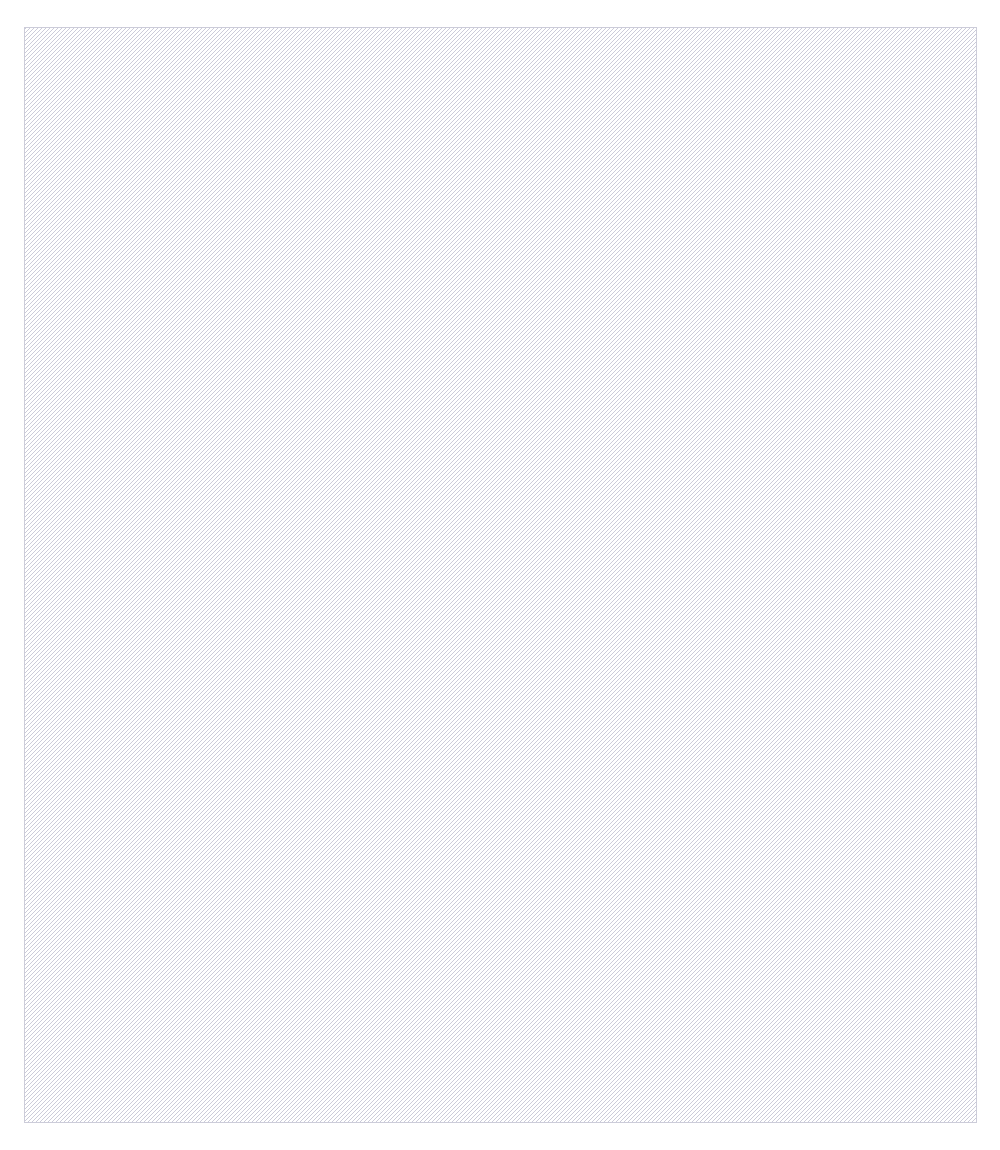

In [18]:
display(floorplan)

### Tap/Endcap Cell Insertion

This places two kinds of cells on the floorplan:

* End cap/boundary cells: Added at the beginning and end of each row. True to
  their name, they "cap off" the core area of a design.
* Tap cells: Placed in a polka dot-ish fashion across the rows. Tap cells
  connect VDD to the nwell and the psubstrate to VSS, which the majority of cells
  do not do themselves to save area- but if you go long enough without one such
  connection you end up with the cell "latching-up"; i.e.; refusing to switch
  back to LO from HI.

  There is a maximum distance between tap cells enforced as part of every
  foundry process.

In [19]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[07:20:24] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=181570;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=914650;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/4-openroad-tapendcapinsertion'…                                                 

[07:20:24] VERBOSE  Logging subprocess to                                                              ]8;id=399028;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=620771;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/4-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                 

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.odb
def,librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.def
sdc,librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/4-openroad-tapendcapinsertion/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:20:31] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_yqeubjeh'…               ]8;id=69014;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=663650;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:20:31] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_yqeubjeh/klayout-render.log'…  ]8;id=97207;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=117846;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.92s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
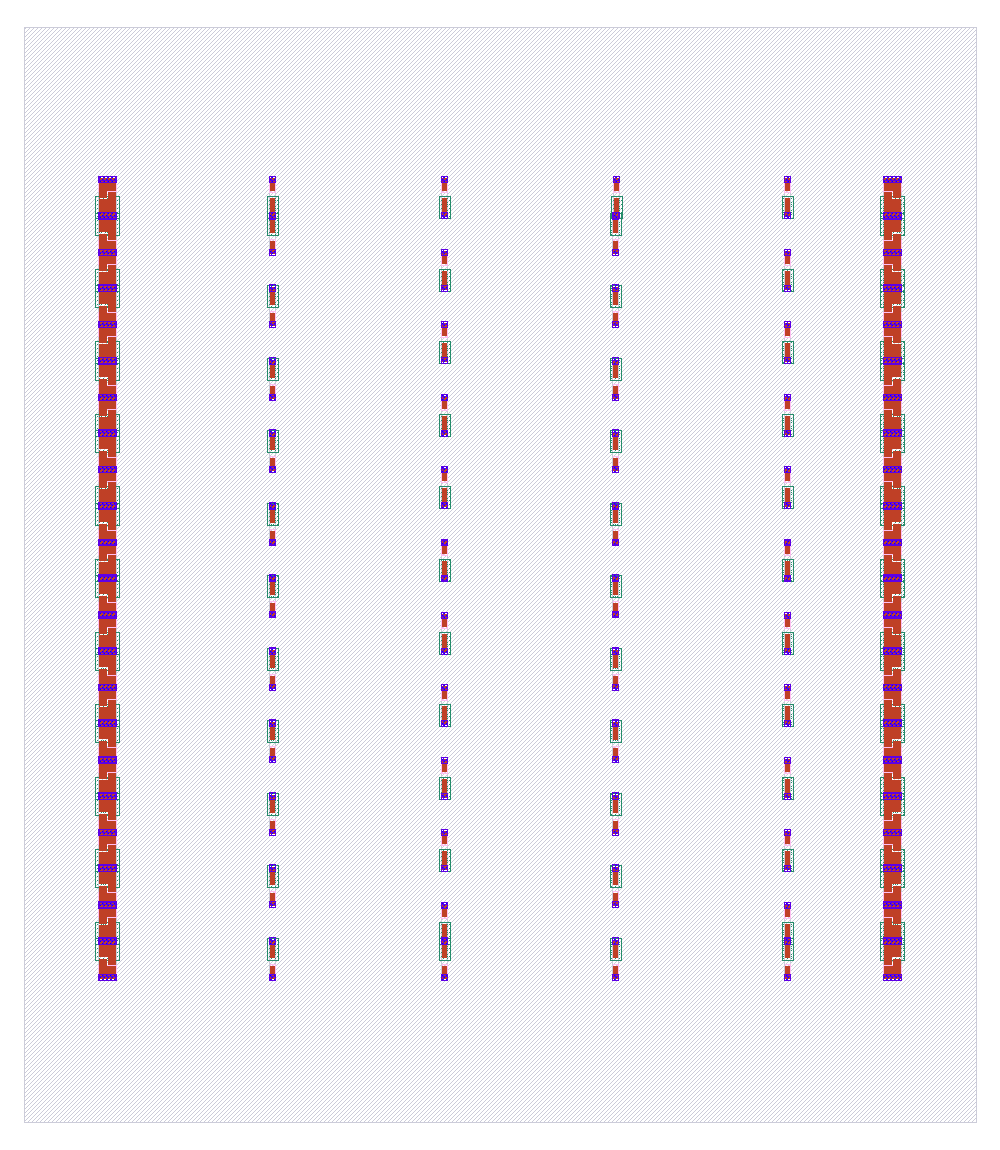

In [20]:
display(tdi)

### I/O Placement

This places metal pins at the edges of the design corresponding to the top level
inputs and outputs for your design. These pins act as the interface with other
designs when you integrate it with other designs.

In [21]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[07:20:41] VERBOSE  Running 'OpenROAD.IOPlacement' at 'librelane_run/5-openroad-ioplacement'…          ]8;id=672936;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=296428;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:20:41] VERBOSE  Logging subprocess to                                                              ]8;id=851706;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=650920;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/5-openroad-ioplacement/openroad-ioplacement.log'…                               

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.odb
def,librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.def
sdc,librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/5-openroad-ioplacement/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:20:45] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_tmxzru7q'…               ]8;id=108621;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=72;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:20:45] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_tmxzru7q/klayout-render.log'…  ]8;id=573374;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=568056;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.54s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
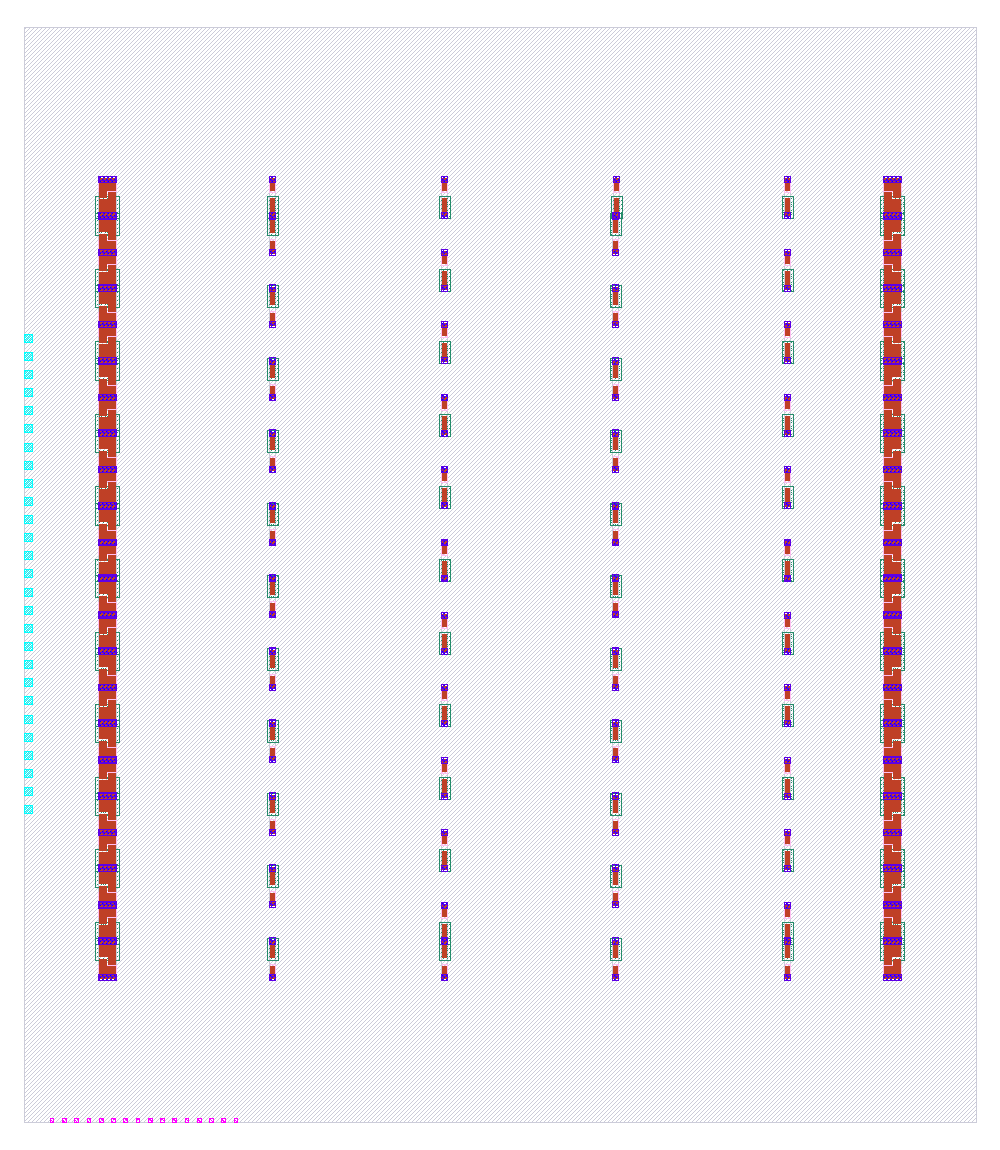

In [22]:
display(ioplace)

### Generating the Power Distribution Network (PDN)

This creates the power distribution network for your design, which is essentially
a plaid pattern of horizontal and vertical "straps" across the design that is
then connected to the rails' VDD and VSS (via the tap cells.)

You can find an explanation of how the power distribution network works at this
link: https://librelane.readthedocs.io/en/latest/usage/hardening_macros.html#pdn-generation

While we typically don't need to mess with the PDN too much, the SPM is a small
design, so we're going to need to make the plaid pattern formed by the PDN a bit
smaller.

In [23]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

[07:21:15] INFO     Loading the incremental configuration has generated the following warnings:       ]8;id=408883;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=534007;file:///content/librelane_ipynb/librelane/config/config.py#333\333]8;;\

[07:21:15] WARNING  The configuration variable 'FP_PDN_VWIDTH' is deprecated. Please check the docs   ]8;id=187130;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=276693;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VWIDTH'.                                        

[07:21:15] WARNING  The configuration variable 'FP_PDN_HWIDTH' is deprecated. Please check the docs   ]8;id=514661;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=972050;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HWIDTH'.                                        

[07:21:15] WARNING  The configuration variable 'FP_PDN_VPITCH' is deprecated. Please check the docs   ]8;id=16099;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=897973;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VPITCH'.                                        

[07:21:15] WARNING  The configuration variable 'FP_PDN_HPITCH' is deprecated. Please check the docs   ]8;id=217201;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=995065;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HPITCH'.                                        

...

Writing layout to '/content/librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.odb
def,librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.def
sdc,librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/6-openroad-generatepdn/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:21:22] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_a0f3caro'…               ]8;id=790646;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=797737;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:21:22] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_a0f3caro/klayout-render.log'…  ]8;id=741470;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=563056;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.14s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
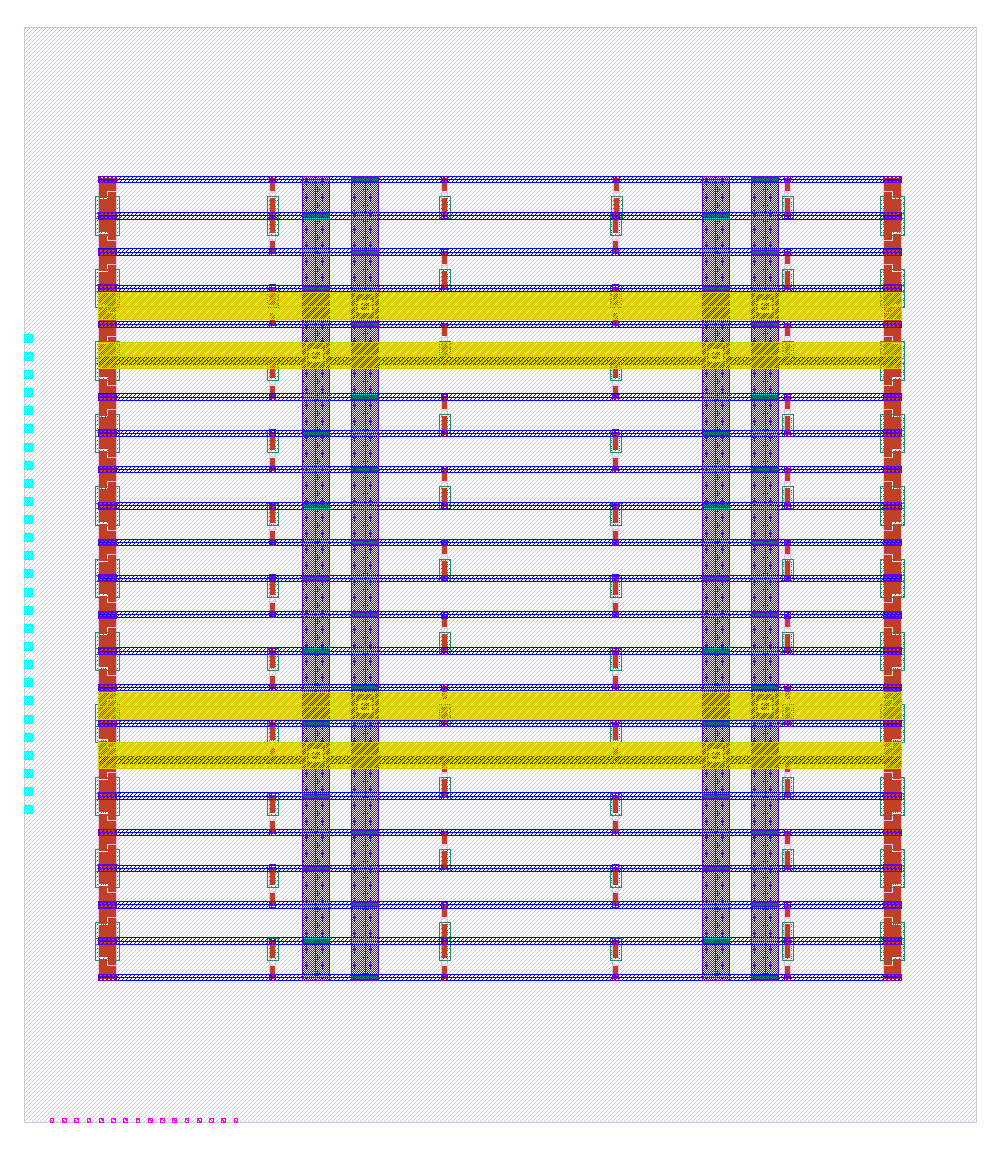

In [24]:
display(pdn)

### Global Placement

Global Placement is deciding on a fuzzy, non-final location for each of the cells,
with the aim of minimizing the distance between cells that are connected
together (more specifically, the total length of the not-yet-created wires that
will connect them).

As you will see in the `.display()` in the second cell below, the placement is
considered "illegal", i.e., not properly aligned with the cell placement grid.
This is addressed by "Detailed Placement", also referred to as "placement
legalization", which is the next step.

In [25]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[07:21:53] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/7-openroad-globalplacement'…  ]8;id=399856;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=97705;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:21:53] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=846819;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=695507;file:///content/librelane_ipynb/librelane/steps/openroad.py#1581\1581]8;;\
                    target density: 62.220700…                                                                     

[07:21:53] VERBOSE  Logging subprocess to                                                              ]8;id=853094;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=360994;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/7-openroad-globalplacement/openroad-globalplacement.log'…                       

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.odb
def,librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.def
sdc,librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/7-openroad-globalplacement/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:23:05] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_b8xnri1s'…               ]8;id=656788;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=991251;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:23:05] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_b8xnri1s/klayout-render.log'…  ]8;id=637166;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=839265;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.44s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
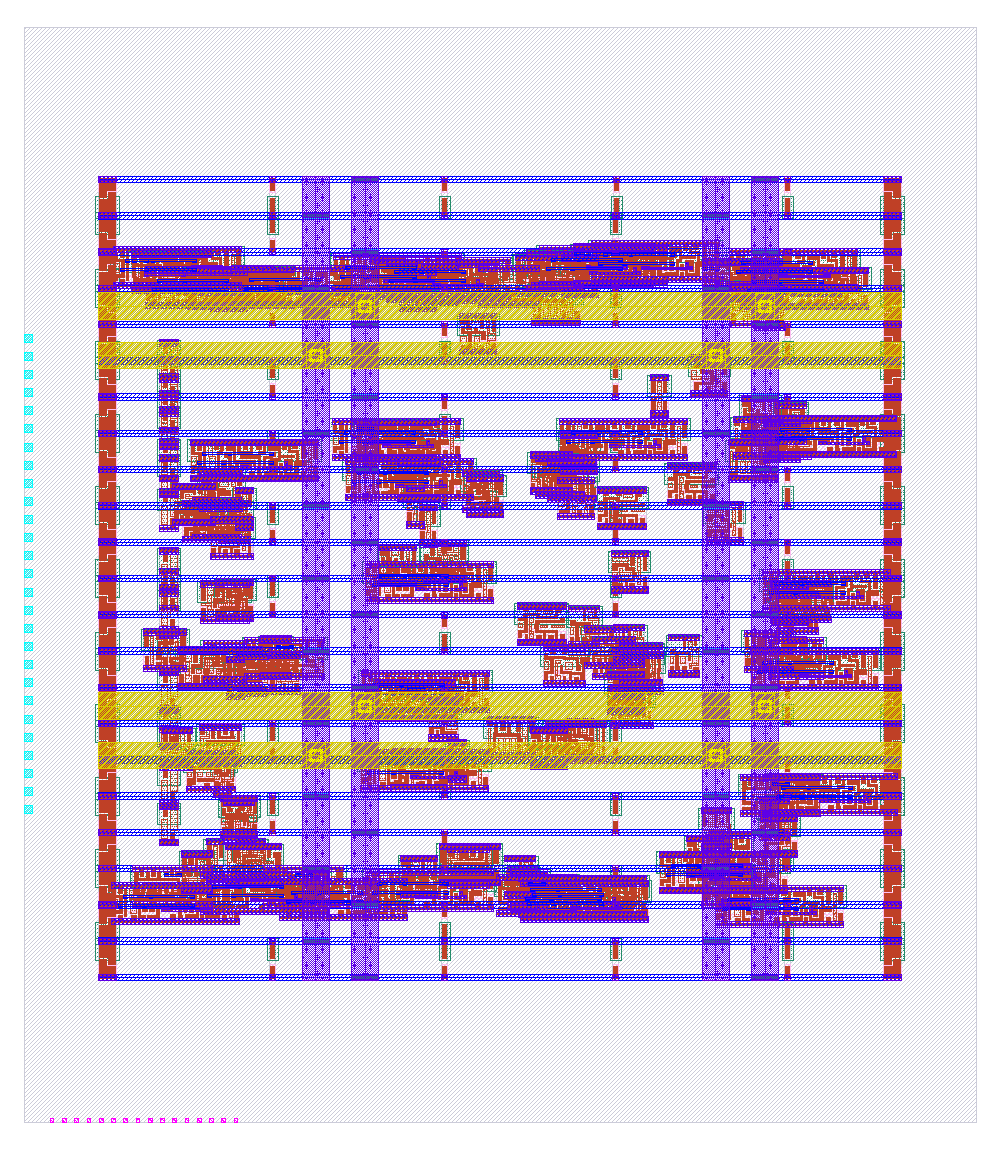

In [26]:
display(gpl)

### Detailed Placement

This aligns the fuzzy placement from before with the grid, "legalizing" it.

In [27]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[07:23:30] VERBOSE  Running 'OpenROAD.DetailedPlacement' at                                            ]8;id=887104;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=624221;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/8-openroad-detailedplacement'…                                                  

[07:23:30] VERBOSE  Logging subprocess to                                                              ]8;id=806889;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=6778;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/8-openroad-detailedplacement/openroad-detailedplacement.log'…                   

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.odb
def,librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.def
sdc,librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/8-openroad-detailedplacement/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:23:35] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_aw2fcmri'…               ]8;id=912617;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=510808;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:23:35] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_aw2fcmri/klayout-render.log'…  ]8;id=654402;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=693894;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.92s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
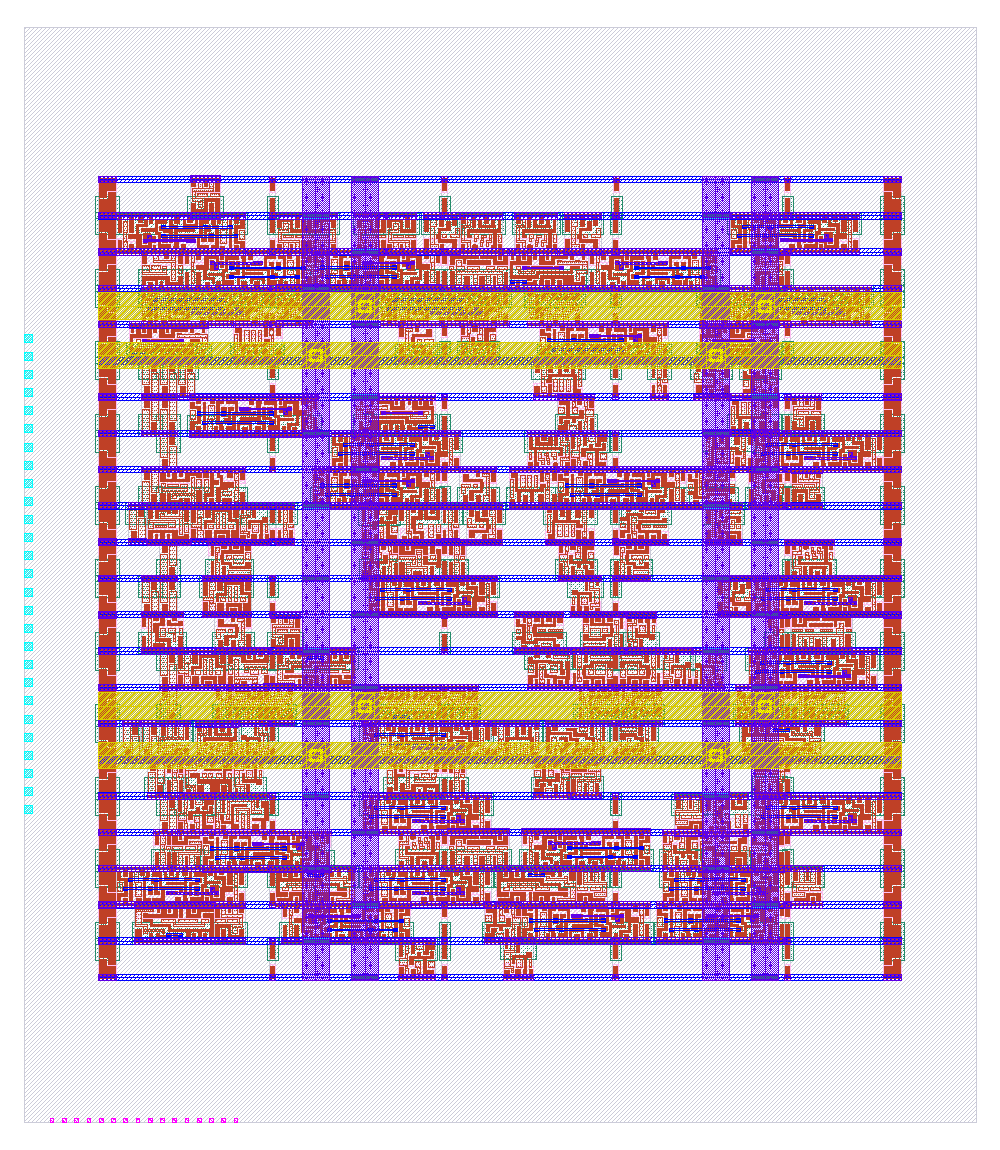

In [28]:
display(dpl)

### Clock Tree Synthesis (CTS)

With the cells now having a final placement, we can go ahead and create what
is known as the clock tree, i.e., the hierarchical set of buffers used
for clock signal to minimize what is known as "clock skew"- variable delay
of the clock cycle from register to register because of factors such as metal
wire length, clock load (number of gates connected to the same clock buffer,)
et cetera.

The CTS step creates the cells and places the between the gaps in the detailed
placement above.

In [34]:
CTS = Step.factory.get("OpenROAD.CTS")

cts = CTS(state_in=dpl.state_out)
cts.start()

────────────────────────────────────────────── Clock Tree Synthesis ───────────────────────────────────────────────

[07:26:00] VERBOSE  Running 'OpenROAD.CTS' at 'librelane_run/12-openroad-cts'…                         ]8;id=109391;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=422421;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:26:00] VERBOSE  Logging subprocess to 'librelane_run/12-openroad-cts/openroad-cts.log'…            ]8;id=121014;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=732222;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner max_tt_025C_1v80…

Reading timing library for the 'max_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.odb
def,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.def
sdc,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:26:20] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_gl5g7zmb'…               ]8;id=342183;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=926904;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:26:20] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_gl5g7zmb/klayout-render.log'…  ]8;id=681986;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=112622;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 16.47s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
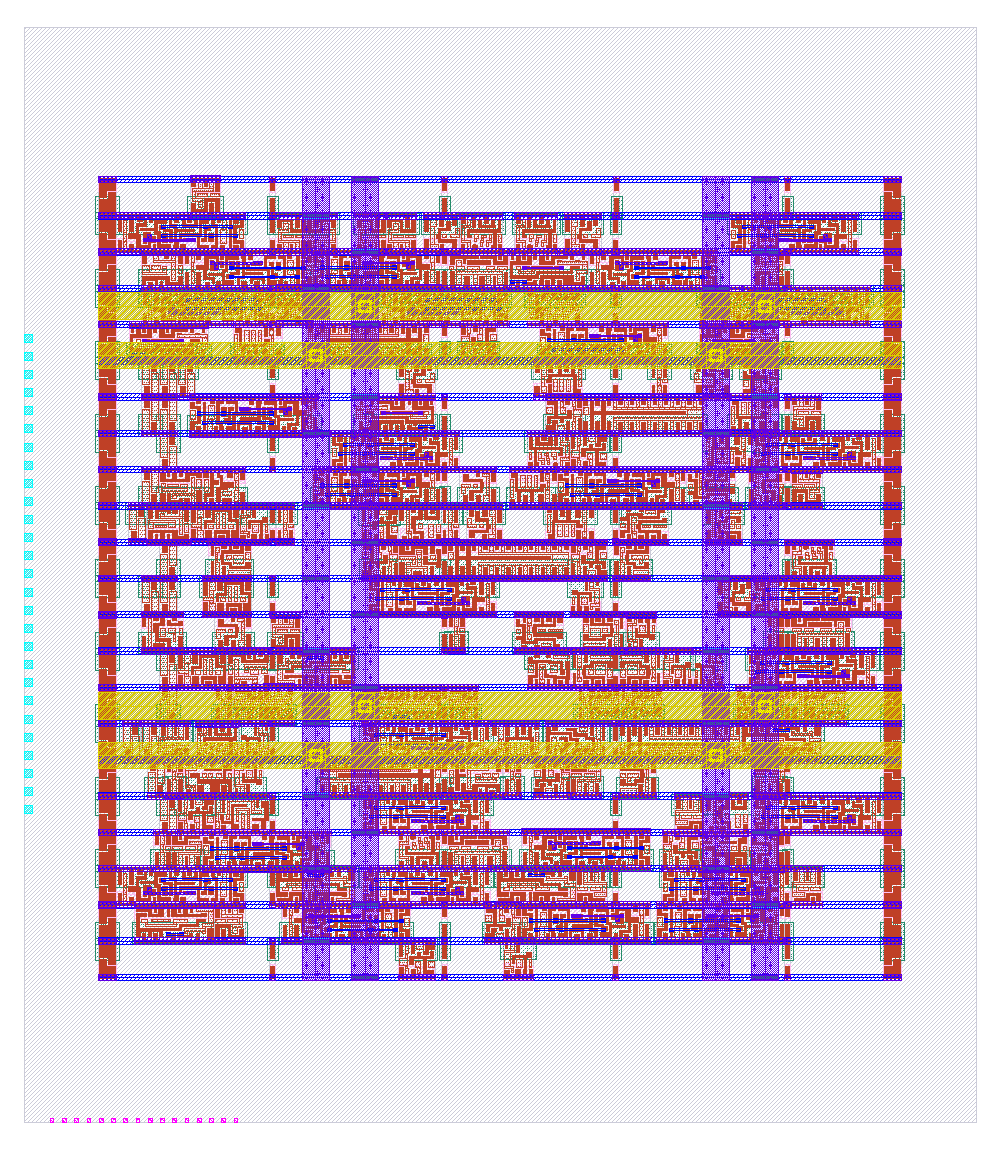

In [35]:
display(cts)

### Global Routing

Global routing "plans" the routes the wires between two gates (or gates and
I/O pins/the PDN) will take. The results of global routing (which are called
"routing guides") are stored in internal data structures and have no effect on
the actual design, so there is no `display()` statement.

In [36]:
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")

grt = GlobalRouting(state_in=cts.state_out)
grt.start()

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[07:27:04] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'librelane_run/13-openroad-globalrouting'…     ]8;id=970373;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=914280;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:27:04] VERBOSE  Logging subprocess to                                                              ]8;id=757963;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=273337;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/13-openroad-globalrouting/openroad-globalrouting.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Multi-Input combinational cell          128    1053.51

Total                                   262    2173.33

Writing OpenROAD database to '/content/librelane_run/13-openroad-globalrouting/tt_um_advaittej_stopwatch.odb'…

Writing layout to '/content/librelane_run/13-openroad-globalrouting/tt_um_advaittej_stopwatch.def'…

Format,Path
nl,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/13-openroad-globalrouting/tt_um_advaittej_stopwatch.odb
def,librelane_run/13-openroad-globalrouting/tt_um_advaittej_stopwatch.def
sdc,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/12-openroad-cts/tt_um_advaittej_stopwatch.pnl.v


### Detailed Routing

Detailed routing uses the guides from Global Routing to actually create wires
on the metal layers and connect the gates, making the connections finally physical.

This is typically the longest step in the flow.

In [37]:
DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")

drt = DetailedRouting(state_in=grt.state_out)
drt.start()

──────────────────────────────────────────────── Detailed Routing ─────────────────────────────────────────────────

[07:28:00] VERBOSE  Running 'OpenROAD.DetailedRouting' at 'librelane_run/14-openroad-detailedrouting'… ]8;id=38809;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=77606;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:28:00] INFO     Running TritonRoute with 2 threads…                                            ]8;id=543946;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=504177;file:///content/librelane_ipynb/librelane/steps/openroad.py#2002\2002]8;;\

[07:28:00] VERBOSE  Logging subprocess to                                                              ]8;id=626919;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=719431;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/14-openroad-detailedrouting/openroad-detailedrouting.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.odb
def,librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.def
sdc,librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/14-openroad-detailedrouting/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:28:46] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_9uwg3zo_'…               ]8;id=149753;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=235726;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:28:46] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_9uwg3zo_/klayout-render.log'…  ]8;id=496690;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=884877;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 46.53s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
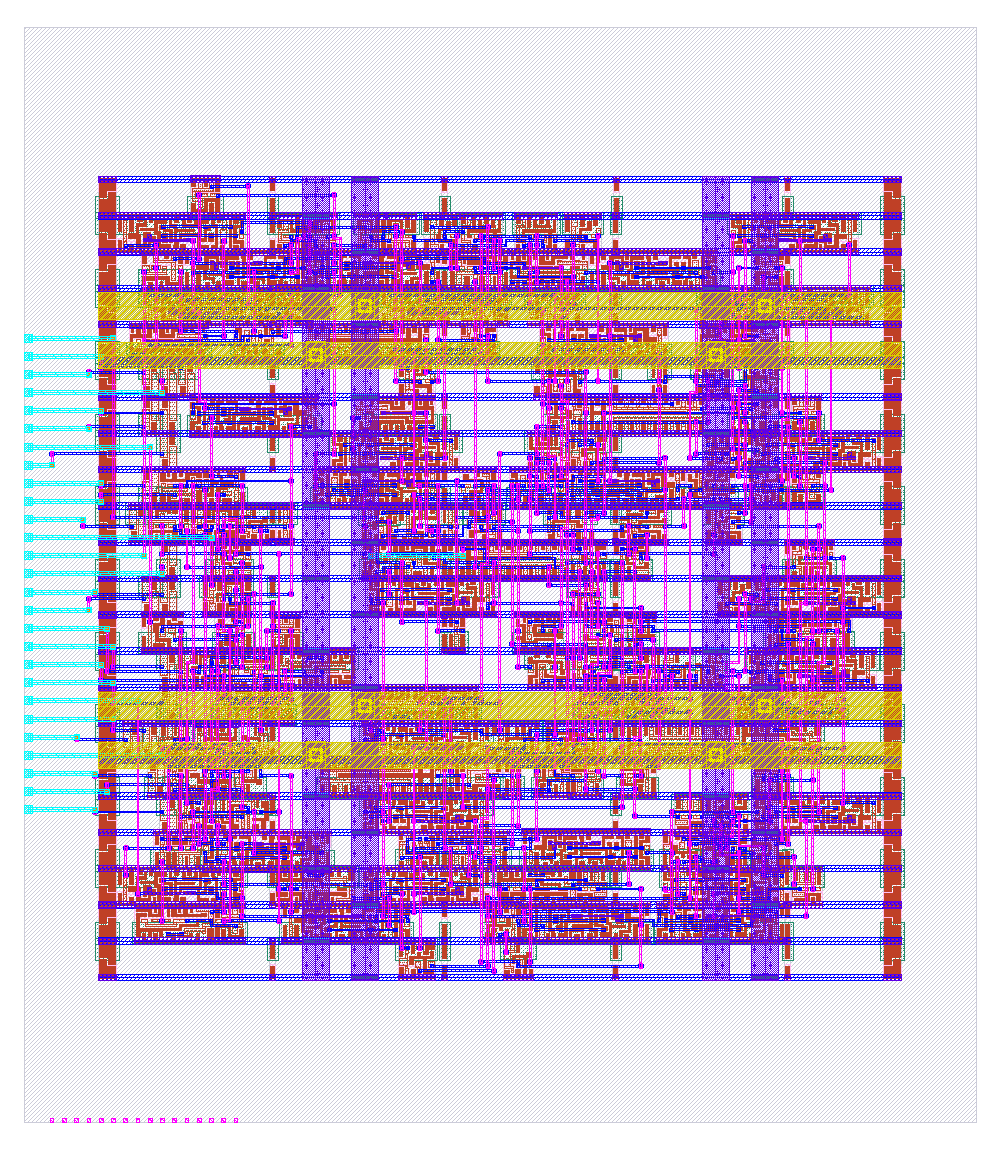

In [38]:
display(drt)

### Fill Insertion

Finally, as we're done placing all the essential cells, the only thing left to
do is fill in the gaps.

We prioritize the use of decap (decoupling capacitor) cells, which
further supports the power distribution network, but when there aren't any
small enough cells, we just use regular fill cells.

In [39]:
FillInsertion = Step.factory.get("OpenROAD.FillInsertion")

fill = FillInsertion(state_in=drt.state_out)
fill.start()

───────────────────────────────────────────────── Fill Insertion ──────────────────────────────────────────────────

[07:28:47] VERBOSE  Running 'OpenROAD.FillInsertion' at 'librelane_run/15-openroad-fillinsertion'…     ]8;id=38386;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=320823;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:28:47] VERBOSE  Logging subprocess to                                                              ]8;id=562503;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=550554;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/15-openroad-fillinsertion/openroad-fillinsertion.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'…

Writing powered netlist to '/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'…

Writing layout to '/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'…

Writing timing constraints to '/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'…

Format,Path
nl,librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v
odb,librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb
def,librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def
sdc,librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc
pnl,librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:29:45] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_ybsv1xji'…               ]8;id=16739;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=336106;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:29:45] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_ybsv1xji/klayout-render.log'…  ]8;id=101098;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=661694;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.02s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
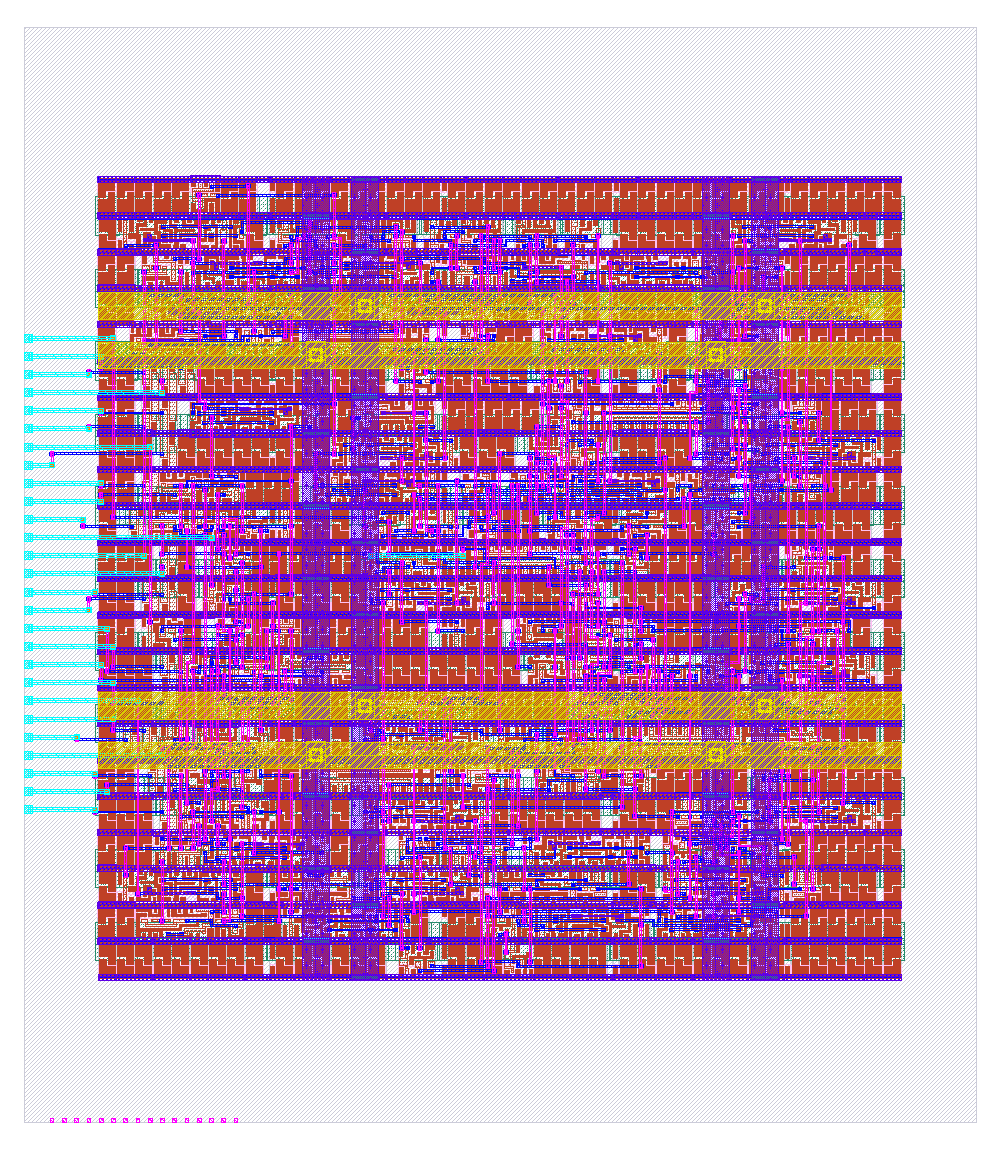

In [40]:
display(fill)

### Parasitics Extraction a.k.a. Resistance/Capacitance Extraction (RCX)

This step does not alter the design- rather, it computes the
[Parasitic elements](https://en.wikipedia.org/wiki/Parasitic_element_(electrical_networks))
of the circuit, which have an effect of timing, as we prepare to do the final
timing analysis.

The parasitic elements are saved in the **Standard Parasitics Exchange Format**,
or SPEF. LibreLane creates a SPEF file for each interconnect corner as described in
the [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
section of the documentation.

In [41]:
RCX = Step.factory.get("OpenROAD.RCX")

rcx = RCX(state_in=fill.state_out)
rcx.start()

─────────────────────────────────── Parasitic Resistance/Capacitance Extraction ───────────────────────────────────

[07:30:07] VERBOSE  Running 'OpenROAD.RCX' at 'librelane_run/16-openroad-rcx'…                         ]8;id=634416;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=311557;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:30:07] INFO     Running RCX for corners matching nom_*                                         ]8;id=556805;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=705405;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/16-openroad-rcx/nom/rcx.log)…                                          

[07:30:07] INFO     Running RCX for corners matching min_*                                         ]8;id=422163;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=336235;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/16-openroad-rcx/min/rcx.log)…                                          

[07:30:07] VERBOSE  Logging subprocess to 'librelane_run/16-openroad-rcx/nom/rcx.log'…                 ]8;id=909364;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=998672;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

...

[07:30:08] INFO     Finished RCX for corners matching min_*.                                       ]8;id=760373;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=710305;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

[07:30:08] INFO     Running RCX for corners matching max_*                                         ]8;id=388934;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=368865;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/16-openroad-rcx/max/rcx.log)…                                          

[07:30:08] VERBOSE  Logging subprocess to 'librelane_run/16-openroad-rcx/max/rcx.log'…                 ]8;id=890420;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=226531;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[07:30:09] INFO     Finished RCX for corners matching max_*.                                       ]8;id=867201;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=132403;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell': 218, 'design__instance__area__stdcell': Decimal('2008.18'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.556905'), 'design__instance__utilization__stdcell': Decimal('0.556905'), 'design__rows': 22, 'design__rows:unithd': 22, 'design__sites': 2882, 'design__sites:unithd': 2882, 'design__instance__count__class:inverter': 9, 'design__instance__area__class:inverter': Decimal('33.7824'), 'design__instance__count__class:sequential_cell': 28, 'design__instance__area__class:sequential_cell': Decimal('735.706'), 'design__instance__count__class:multi_input_combinational_cell': 128, 'design__instance__area__class:multi_input_combinational_cell': Decimal('1053.51'), 'flow__warnings__count': 0, 'flow__errors__count': 0, 'flow__warnings__count:ODB-0220': 2, 'flow__warnings__type_count': 0, 'design__instance__count__class:fill_cell': 478, 'design__instance__area__class:fill_cell': Decimal('1597.78'), 'design__instance__count__class:tap_cell': 48, 'design__instance__area__class:tap_cell': Decimal('60.0576'), 'floorplan__design__io': 43, 'design__io__hpwl': 1211760, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count': 0, 'design__instance__displacement__total': Decimal('33.974'), 'design__instance__displacement__mean': Decimal('0.129'), 'design__instance__displacement__max': Decimal('5.544'), 'route__wirelength__estimated': Decimal('2868.2'), 'design__violations': 0, 'design__instance__count__class:clock_buffer': 5, 'design__instance__area__class:clock_buffer': Decimal('125.12'), 'flow__warnings__count:STA-1140': 6, 'global_route__vias': 1216, 'global_route__wirelength': 5664, 'route__net': 189, 'route__net__special': 2, 'route__drc_errors__iter:0': 21, 'route__wirelength__iter:0': 3210, 'route__drc_errors__iter:1': 0, 'route__wirelength__iter:1': 3189, 'route__drc_errors': 0, 'route__wirelength': 3189, 'route__vias': 1198, 'route__vias__singlecut': 1198, 'route__vias__multicut': 0, 'antenna__violating__nets': 0, 'antenna__violating__pins': 0, 'flow__warnings__count:DRT-0349': 10}}

### Static Timing Analysis (Post-PnR)

STA is a process that verifies that a chip meets certain constraints on clock
and data timings to run at its rated clock speed. See [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
in the documentation for more info.

---

This step generates two kinds of files:
* `.lib`: Liberty™-compatible Library files. Can be used to do static timing
  analysis when creating a design with this design as a sub-macro.
* `.sdf`: Standard Delay Format. Can be used with certain simulation software
  to do *dynamic* timing analysis.

Unfortunately, the `.lib` files coming out of LibreLane right now are not super
reliable for timing purposes and are only provided for completeness.

When using LibreLane-created macros withing other designs, it is best to use the
macro's final netlist and extracted parasitics instead.

In [42]:
STAPostPNR = Step.factory.get("OpenROAD.STAPostPNR")

sta_post_pnr = STAPostPNR(state_in=rcx.state_out)
sta_post_pnr.start()

──────────────────────────────────────── Static Timing Analysis (Post-PnR) ────────────────────────────────────────

[07:30:47] VERBOSE  Running 'OpenROAD.STAPostPNR' at 'librelane_run/17-openroad-stapostpnr'…           ]8;id=857880;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=287654;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:30:47] INFO     Starting STA for the nom_tt_025C_1v80 timing corner…                            ]8;id=111989;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=65444;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[07:30:47] INFO     Starting STA for the nom_ss_100C_1v60 timing corner…                            ]8;id=568637;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=682722;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[07:30:47] VERBOSE  Logging subprocess to                                                              ]8;id=408957;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=282877;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/sta.log'…                               

...

[07:31:00] INFO     Finished STA for the max_ff_n40C_1v95 timing corner.                            ]8;id=961363;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=390178;file:///content/librelane_ipynb/librelane/steps/openroad.py#762\762]8;;\

[07:31:00] VERBOSE  Logging subprocess to                                                              ]8;id=915579;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=360359;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log'…                

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┓
┃                      ┃       ┃       ┃      ┃       ┃ of   ┃       ┃      ┃       ┃      ┃ of    ┃      ┃       ┃
┃                      ┃       ┃ Reg   ┃      ┃       ┃ whi… ┃       ┃ Reg  ┃       ┃      ┃ which ┃      ┃       ┃
┃                      ┃ Hold  ┃ to    ┃      ┃ Hold  ┃ reg  ┃ Setup ┃ to   ┃       ┃ Set… ┃ reg   ┃ Max  ┃ Max   ┃
┃                      ┃ Worst ┃ Reg   ┃ Hold ┃ Vio   ┃ to   ┃ Worst ┃ Reg  ┃ Setup ┃ Vio  ┃ to    ┃ Cap  ┃ Slew  ┃
┃ Corner/Group         ┃ Slack ┃ Paths ┃ TNS  ┃ Count ┃ reg  ┃ Slack ┃ Pat… ┃ TNS   ┃ Cou… ┃ reg   ┃ Vio… ┃ Viol… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━┩
│ Overall              │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 74.9… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 31    │
│ nom_tt_025C_1v80     │ 0.24… │ 0.24… │ 0.0… │ 0     │ 0    │ 77.7… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ nom_ss_100C_1v60     │ 0.73… │ 0.73… │ 0.0… │ 0     │ 0    │ 74.9… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 31    │
│ nom_ff_n40C_1v95     │ 0.06… │ 0.06… │ 0.0… │ 0     │ 0    │ 78.6… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ min_tt_025C_1v80     │ 0.24… │ 0.24… │ 0.0… │ 0     │ 0    │ 77.7… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ min_ss_100C_1v60     │ 0.73… │ 0.73… │ 0.0… │ 0     │ 0    │ 75.0… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 31    │
│ min_ff_n40C_1v95     │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 78.6… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ max_tt_025C_1v80     │ 0.24… │ 0.24… │ 0.0… │ 0     │ 0    │ 77.7… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ max_ss_100C_1v60     │ 0.74… │ 0.74… │ 0.0… │ 0     │ 0    │ 74.9… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 31    │
│ max_ff_n40C_1v95     │ 0.06… │ 0.06… │ 0.0… │ 0     │ 0    │ 78.6… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
└──────────────────────┴───────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┘

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                      ┃ Hold     ┃ Reg to   ┃          ┃          ┃ of which  ┃ Setup    ┃           ┃          ┃           ┃ of which ┃           ┃          ┃
┃                      ┃ Worst    ┃ Reg      ┃          ┃ Hold Vio ┃ reg to    ┃ Worst    ┃ Reg to    ┃ Setup    ┃ Setup Vio ┃ reg to   ┃ Max Cap   ┃ Max Slew ┃
┃ Corner/Group         ┃ Slack    ┃ Paths    ┃ Hold TNS ┃ Count    ┃ reg       ┃ Slack    ┃ Reg Paths ┃ TNS      ┃ Count     ┃ reg      ┃ Violatio… ┃ Violati… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ Overall              │ 0.0589   │ 0.0589   │ 0.0000   │ 0        │ 0         │ 74.9417  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 31       │
│ nom_tt_025C_1v80     │ 0.2437   │ 0.2437   │ 0.0000   │ 0        │ 0         │ 77.7407  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ nom_ss_100C_1v60     │ 0.7377   │ 0.7377   │ 0.0000   │ 0        │ 0         │ 74.9773  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 31       │
│ nom_ff_n40C_1v95     │ 0.0601   │ 0.0601   │ 0.0000   │ 0        │ 0         │ 78.6111  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ min_tt_025C_1v80     │ 0.2419   │ 0.2419   │ 0.0000   │ 0        │ 0         │ 77.7562  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ min_ss_100C_1v60     │ 0.7350   │ 0.7350   │ 0.0000   │ 0        │ 0         │ 75.0073  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 31       │
│ min_ff_n40C_1v95     │ 0.0589   │ 0.0589   │ 0.0000   │ 0        │ 0         │ 78.6203  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ max_tt_025C_1v80     │ 0.2460   │ 0.2460   │ 0.0000   │ 0        │ 0         │ 77.7231  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ max_ss_100C_1v60     │ 0.7413   │ 0.7413   │ 0.0000   │ 0        │ 0         │ 74.9417  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 31       │
│ max_ff_n40C_1v95     │ 0.0617   │ 0.0617   │ 0.0000   │ 0        │ 0         │ 78.6006  │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
└──────────────────────┴──────────┴──────────┴──────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┘

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.lib')}, 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell': 218, 'design__instance__area__stdcell': Decimal('2008.18'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'desi

### Stream-out

Stream-out is the process of converting the designs from the abstract formats
using during floorplanning, placement and routing into a concrete format called
GDSII (lit. Graphic Design System 2), which is the final file that is then sent
for fabrication.

In [43]:
StreamOut = Step.factory.get("KLayout.StreamOut")

gds = StreamOut(state_in=sta_post_pnr.state_out)
gds.start()

─────────────────────────────────────────── GDSII Stream Out (KLayout) ────────────────────────────────────────────

[07:31:25] VERBOSE  Running 'KLayout.StreamOut' at 'librelane_run/18-klayout-streamout'…               ]8;id=525619;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=994906;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:31:25] VERBOSE  Logging subprocess to 'librelane_run/18-klayout-streamout/klayout-streamout.log'…  ]8;id=201934;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=31690;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[INFO] Clearing cells…

[INFO] Merging GDS files…

...

[INFO] Checking for missing GDS…

[INFO] All LEF cells have matching GDS cells.

[INFO] Writing out GDS '/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.klayout.gds'…

[INFO] Done.

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.klayout.gds'), 'gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.gds'), 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell': 218, 'design__instance__area__stdcell': Decimal('2008.18'), 'design__instance__count__macros': 0

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[07:31:38] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_y7nxvj3r'…               ]8;id=979718;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=303480;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:31:38] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_y7nxvj3r/klayout-render.log'…  ]8;id=210899;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=402985;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.62s
#### Views updated:
* GDSII Stream (KLayout)
* GDSII Stream
#### Preview:
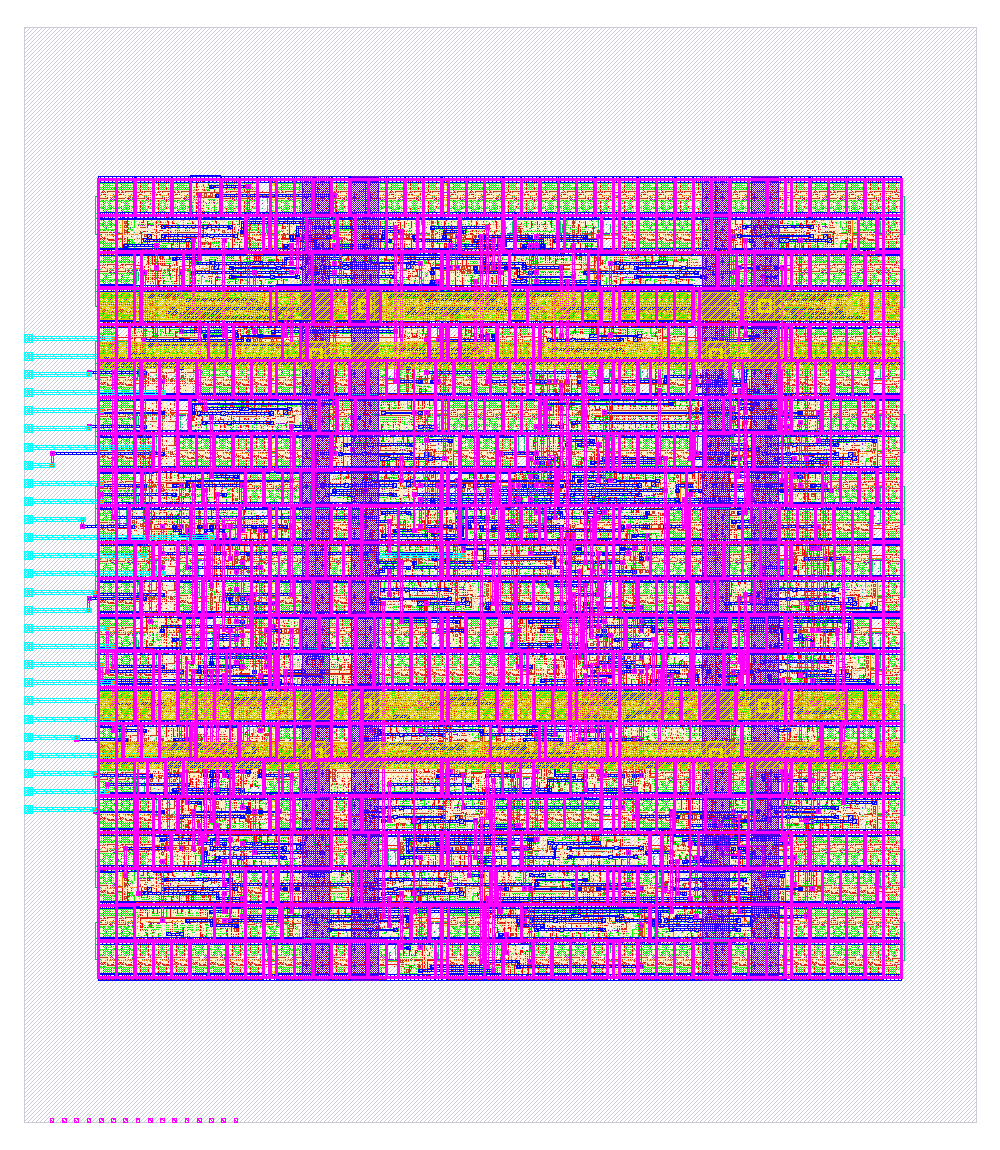

In [44]:
display(gds)

### Design Rule Checks (DRC)

DRC determines that the final layout does not violate any of the rules set by
the foundry to ensure the design is actually manufacturable- for example,
not enough space between two wires, *too much* space between tap cells, and so
on.

A design not passing DRC will typically be rejected by the foundry, who
also run DRC on their side.

In [45]:
DRC = Step.factory.get("Magic.DRC")

drc = DRC(state_in=gds.state_out)
drc.start()

─────────────────────────────────────────────── Design Rule Checks ────────────────────────────────────────────────

[07:32:40] VERBOSE  Running 'Magic.DRC' at 'librelane_run/19-magic-drc'…                               ]8;id=946767;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=124180;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:32:40] VERBOSE  Logging subprocess to 'librelane_run/19-magic-drc/magic-drc.log'…                  ]8;id=95697;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=662556;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

[INFO] Should be divided by 3 or 4

[INFO] DRC Checking DONE (/content/librelane_run/19-magic-drc/reports/drc.magic.rpt)

[INFO] Saving mag view with DRC errors                                                                             
(/content/librelane_run/19-magic-drc/views/tt_um_advaittej_stopwatch.drc.mag)

[INFO] Saved

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.klayout.gds'), 'gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.gds'), 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell': 218, 'design__instance__area__stdcell': Decimal('2008.18'), 'design__instance__count__macros': 0

### SPICE Extraction for Layout vs. Schematic Check

This step tries to reconstruct a SPICE netlist from the GDSII file, so it can
later be used for the **Layout vs. Schematic** (LVS) check.

In [46]:
SpiceExtraction = Step.factory.get("Magic.SpiceExtraction")

spx = SpiceExtraction(state_in=drc.state_out)
spx.start()

───────────────────────────────────────────── SPICE Model Extraction ──────────────────────────────────────────────

[07:32:47] VERBOSE  Running 'Magic.SpiceExtraction' at 'librelane_run/20-magic-spiceextraction'…       ]8;id=573077;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=451101;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:32:47] VERBOSE  Logging subprocess to                                                              ]8;id=81432;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=191710;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/20-magic-spiceextraction/magic-spiceextraction.log'…                            

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

Extracting sky130_fd_sc_hd__and2b_2 into sky130_fd_sc_hd__and2b_2.ext:

Extracting sky130_fd_sc_hd__xor2_2 into sky130_fd_sc_hd__xor2_2.ext:

Extracting tt_um_advaittej_stopwatch into tt_um_advaittej_stopwatch.ext:

exttospice finished.

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.klayout.gds'), 'gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.gds'), 'spice': Path('/content/librelane_run/20-magic-spiceextraction/tt_um_advaittej_stopwatch.spice'), 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell'

### Layout vs. Schematic (LVS)

A comparison between the final Verilog netlist (from PnR) and the final
SPICE netlist (extracted.)

This check effectively compares the physically implemented circuit to the final
Verilog netlist output by OpenROAD.

The idea is, if there are any disconnects, shorts or other mismatches in the
physical implementation that do not exist in the logical view of the design,
they would be caught at this step.

Common issues that result in LVS violations include:
* Lack of fill cells or tap cells in the design
* Two unrelated signals to be shorted, or a wire to be disconnected (most
  commonly seen with misconfigured PDN)

Chips with LVS errors are typically dead on arrival.

In [47]:
LVS = Step.factory.get("Netgen.LVS")

lvs = LVS(state_in=spx.state_out)
lvs.start()

─────────────────────────────────────────────────── Netgen LVS ────────────────────────────────────────────────────

[07:33:22] VERBOSE  Running 'Netgen.LVS' at 'librelane_run/21-netgen-lvs'…                             ]8;id=688496;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=341448;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[07:33:22] VERBOSE  Logging subprocess to 'librelane_run/21-netgen-lvs/netgen-lvs.log'…                ]8;id=642457;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=882434;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Netgen 1.5.316 compiled on Tue Feb 10 11:09:08 UTC 2026

Warning: netgen command 'format' use fully-qualified name '::netgen::format'

...

Circuits match uniquely.

.

Logging to file "/content/librelane_run/21-netgen-lvs/reports/lvs.netgen.rpt" disabled

LVS Done.

{'nl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.nl.v'), 'odb': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.odb'), 'def': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.def'), 'sdc': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.sdc'), 'pnl': Path('/content/librelane_run/15-openroad-fillinsertion/tt_um_advaittej_stopwatch.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/16-openroad-rcx/nom/tt_um_advaittej_stopwatch.nom.spef'), 'min_*': Path('/content/librelane_run/16-openroad-rcx/min/tt_um_advaittej_stopwatch.min.spef'), 'max_*': Path('/content/librelane_run/16-openroad-rcx/max/tt_um_advaittej_stopwatch.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/nom_tt_025C_1v80/tt_um_advaittej_stopwatch__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ss_100C_1v60/tt_um_advaittej_stopwatch__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/nom_ff_n40C_1v95/tt_um_advaittej_stopwatch__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/min_tt_025C_1v80/tt_um_advaittej_stopwatch__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/min_ss_100C_1v60/tt_um_advaittej_stopwatch__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/min_ff_n40C_1v95/tt_um_advaittej_stopwatch__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/17-openroad-stapostpnr/max_tt_025C_1v80/tt_um_advaittej_stopwatch__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/17-openroad-stapostpnr/max_ss_100C_1v60/tt_um_advaittej_stopwatch__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/17-openroad-stapostpnr/max_ff_n40C_1v95/tt_um_advaittej_stopwatch__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.klayout.gds'), 'gds': Path('/content/librelane_run/18-klayout-streamout/tt_um_advaittej_stopwatch.gds'), 'spice': Path('/content/librelane_run/20-magic-spiceextraction/tt_um_advaittej_stopwatch.spice'), 'metrics': {'design__instance__count': 696, 'design__instance__area': Decimal('3605.96'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 71.42 82.14', 'design__core__bbox': '5.52 10.88 65.78 70.72', 'design__io': 45, 'design__die__area': Decimal('5866.44'), 'design__core__area': Decimal('3605.96'), 'design__instance__count__stdcell'